# Day 4-1: COVID-19 흉부 X-ray EDA

**강의 시간**: 1.5시간  
**학습 목표**:
- COVID-19 Radiography Database 탐색
- 의료 이미지 특성 이해
- Class Imbalance 확인
- Baseline 모델 구축

**데이터셋**: COVID-19 Radiography Database (Kaggle)  
**크기**: ~1GB (21,165 images)  
**클래스**: 4개 (COVID, Normal, Lung_Opacity, Viral Pneumonia)

## 🔧 0. 환경 설정

In [1]:
# 라이브러리 설치
%pip install -q 'mlflow>=2,<3' dagshub tensorflow opencv-python scikit-learn

print("✅ 라이브러리 설치 완료!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.4/263.4 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 99.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.4/808.4 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

# TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# MLflow
import mlflow
import dagshub

# 재현성
np.random.seed(42)
tf.random.set_seed(42)

print(f"✅ TensorFlow {tf.__version__}")
print(f"✅ GPU: {tf.test.is_gpu_available()}")

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


✅ TensorFlow 2.19.0
✅ GPU: True


In [3]:
# 시각화 설정
sns.set_style('whitegrid')

# 1) 폰트 파일 직접 다운로드 (런타임 재시작 불필요)
!wget -q -O NanumGothic.ttf -L "https://fonts.gstatic.com/ea/nanumgothic/v5/NanumGothic-Regular.ttf"

import matplotlib.font_manager as fm

# 폰트 파일 경로
font_path = "NanumGothic.ttf"

# 폰트 매니저에 폰트 추가
fm.fontManager.addfont(font_path)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# 폰트 속성 설정
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

In [4]:
# MLflow 설정
import mlflow
import dagshub

# 🔥 본인의 정보로 수정!
repo_owner = 'dev.codecompose'  # 본인의 Dagshub username
repo_name = 'deeplearning-bootcamp'  # 생성한 repository 이름 (예: deeplearning-bootcamp)

dagshub.init(repo_owner=repo_owner, repo_name=repo_name, mlflow=True)
mlflow.set_experiment('day4-covid-xray-classification')

print("✅ MLflow 설정 완료!")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=b5f90bd4-4b2a-4fb5-895a-326eed0dab01&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=80c64ed8107f3d13709c26a45731c6fd2f630a08fe3b381e008db1cfb5a6b988




Accessing as dev.codecompose

Initialized MLflow to track repo "dev.codecompose/deeplearning-bootcamp"

Repository dev.codecompose/deeplearning-bootcamp initialized!

✅ MLflow 설정 완료!


## 📦 1. 데이터 다운로드

### Kaggle API 설정

**사전 준비**:
1. Kaggle 계정 생성 (https://www.kaggle.com)
2. Account → API → "Create New API Token"
3. `kaggle.json` 다운로드

In [5]:
import os
from google.colab import userdata

# 1. [가장 중요] kaggle 라이브러리를 임포트하기 "전"에 환경 변수를 먼저 설정합니다.
# 보안 비밀에 KAGGLE_USERNAME(내 아이디)과 KAGGLE_API_TOKEN(키 문자열)이 있어야 합니다.
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_API_TOKEN')      # Python API용 표준 이름
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN') # 최신 토큰 방식 호환용

# 2. 환경 변수가 설정된 후 비로소 라이브러리를 불러옵니다.
try:
    from kaggle.api.kaggle_api_extended import KaggleApi

    api = KaggleApi()
    api.authenticate() # 이제 환경 변수를 인식하고 에러 없이 통과합니다.

    # 3. 데이터셋 다운로드 실행
    dataset_id = 'tawsifurrahman/covid19-radiography-database'
    print(f"📥 {dataset_id} 다운로드 시작...")

    api.dataset_download_files(
        dataset_id,
        path='./data',
        unzip=True,
        quiet=False
    )

    print("\n✅ 다운로드 및 압축 해제 완료!")

except Exception as e:
    print(f"\n❌ 오류 발생: {e}")

📥 tawsifurrahman/covid19-radiography-database 다운로드 시작...
Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database


100%|██████████| 778M/778M [00:07<00:00, 113MB/s] 


✅ 다운로드 및 압축 해제 완료!


## 🔍 2. 데이터 탐색

In [6]:
# 데이터 구조 확인
data_dir = Path('./data/COVID-19_Radiography_Dataset')

print("="*60)
print("  데이터셋 구조")
print("="*60)

class_names = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
class_counts = {}

for class_name in class_names:
    image_dir = data_dir / class_name / 'images'
    num_images = len(list(image_dir.glob('*.png')))
    class_counts[class_name] = num_images
    print(f"{class_name:20s}: {num_images:5d} images")

total = sum(class_counts.values())
print("="*60)
print(f"{'Total':20s}: {total:5d} images")
print("="*60)

  데이터셋 구조
COVID               :  3616 images
Lung_Opacity        :  6012 images
Normal              : 10192 images
Viral Pneumonia     :  1345 images
Total               : 21165 images


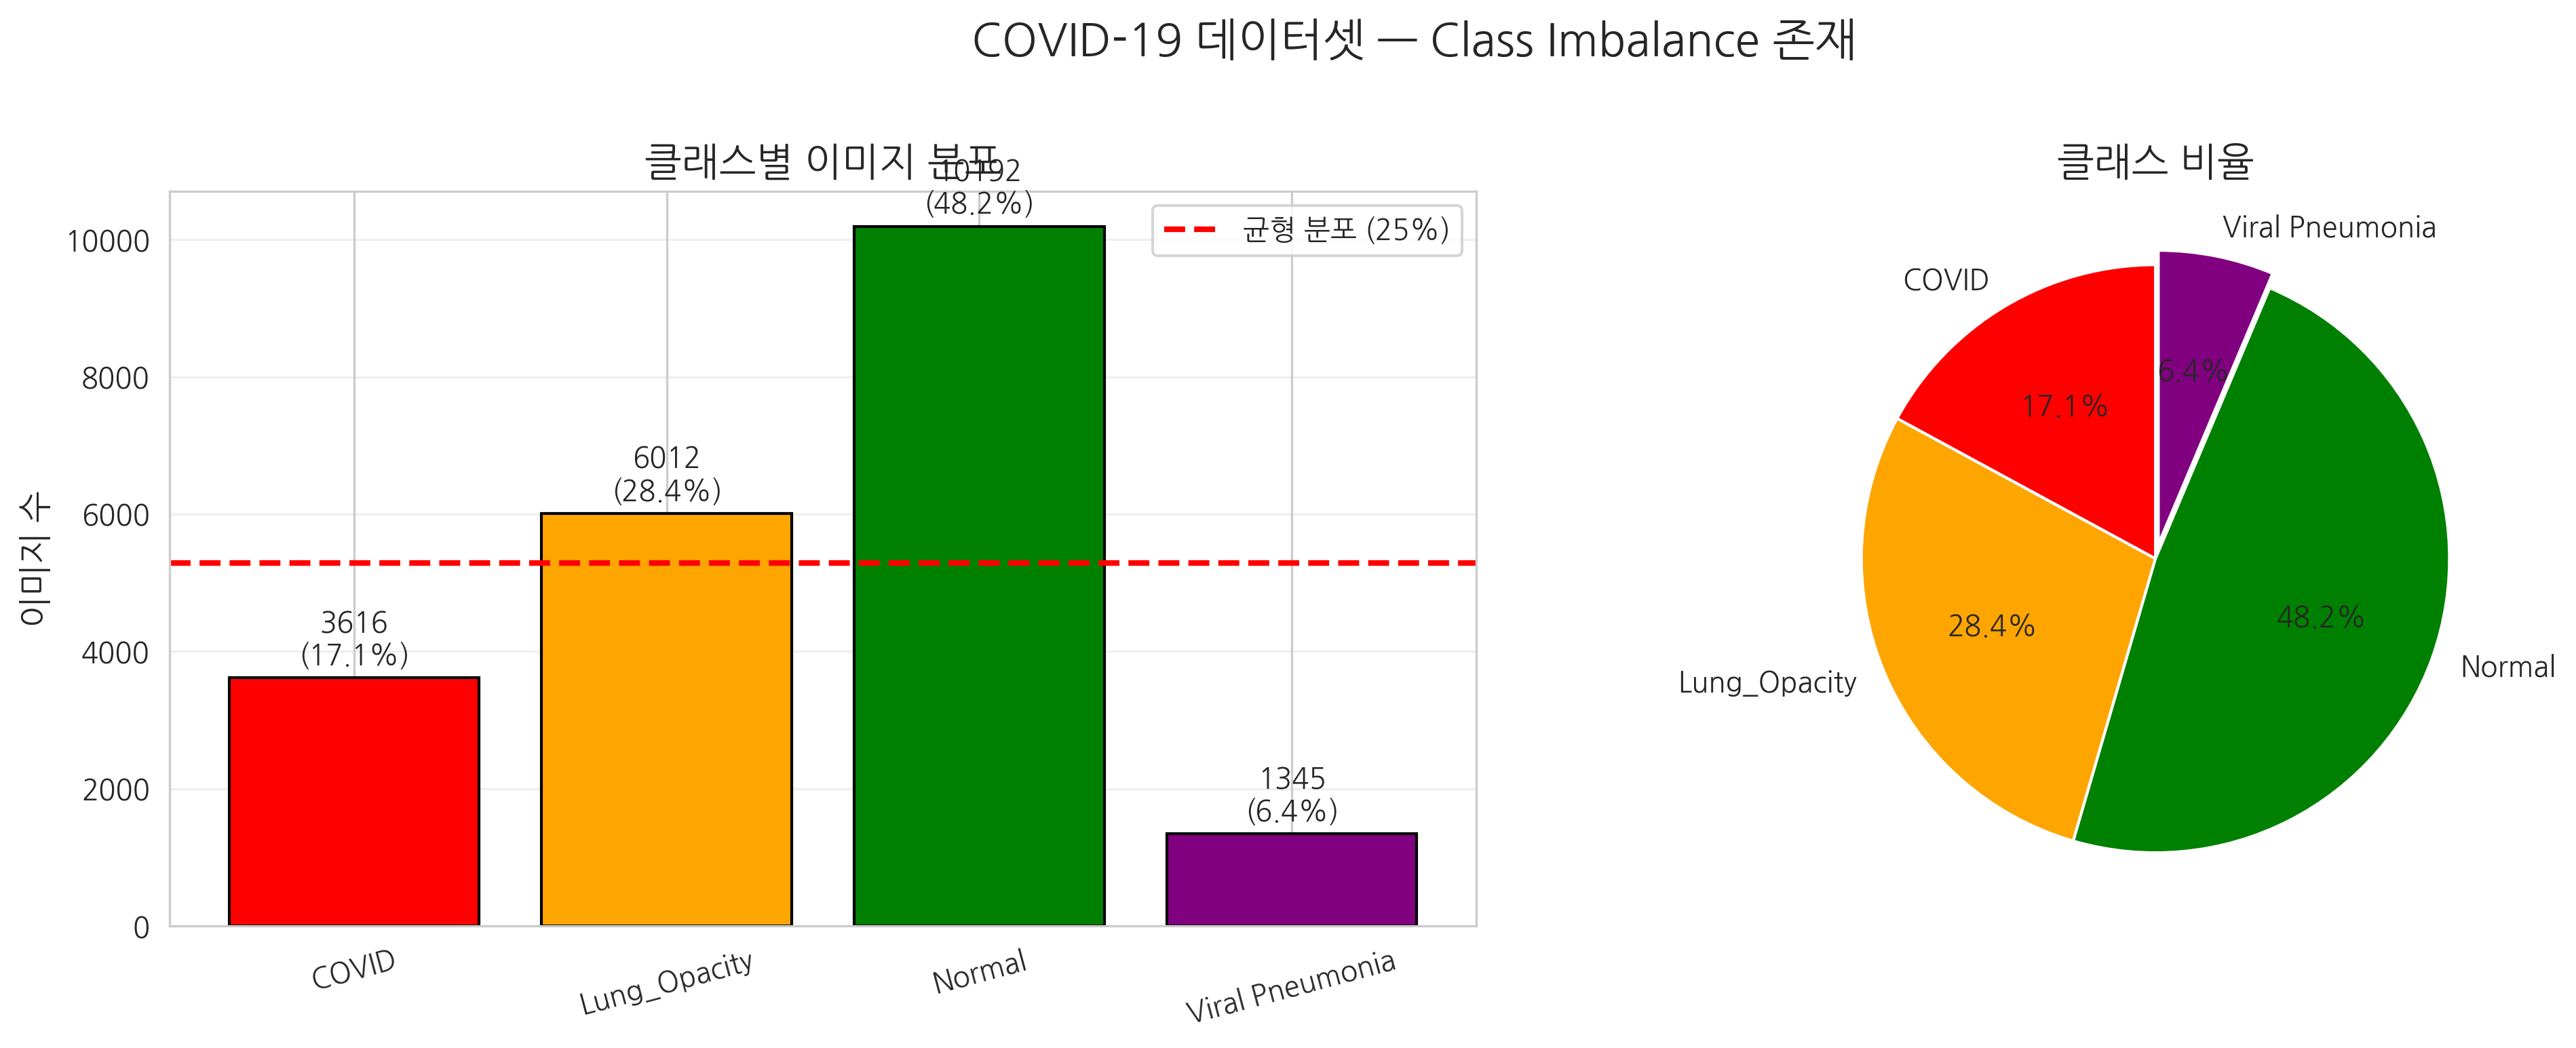


⚠️ Class Imbalance 발견!
   Normal (최다): 10,192개
   Viral Pneumonia (최소): 1,345개
   비율: 7.6:1


In [7]:
# 클래스 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['red', 'orange', 'green', 'purple']
bars = axes[0].bar(class_names, class_counts.values(), color=colors, edgecolor='black')
axes[0].set_ylabel('이미지 수', fontweight='bold', fontsize=12)
axes[0].set_title('클래스별 이미지 분포', fontweight='bold', fontsize=14)
axes[0].tick_params(axis='x', rotation=15)

for bar, (name, count) in zip(bars, class_counts.items()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{count}\n({count/total*100:.1f}%)',
                ha='center', fontweight='bold', fontsize=10)

axes[0].axhline(total/4, color='red', linestyle='--', linewidth=2,
                label='균형 분포 (25%)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
explode = [0.05 if count < 2000 else 0 for count in class_counts.values()]
axes[1].pie(class_counts.values(), labels=class_names, autopct='%1.1f%%',
            colors=colors, explode=explode, startangle=90)
axes[1].set_title('클래스 비율', fontweight='bold', fontsize=14)

plt.suptitle('COVID-19 데이터셋 — Class Imbalance 존재',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n⚠️ Class Imbalance 발견!")
print(f"   Normal (최다): {class_counts['Normal']:,}개")
print(f"   Viral Pneumonia (최소): {class_counts['Viral Pneumonia']:,}개")
print(f"   비율: {class_counts['Normal'] / class_counts['Viral Pneumonia']:.1f}:1")

## 🖼️ 3. 샘플 이미지 시각화

In [8]:
# 각 클래스별 샘플 이미지 로드
fig, axes = plt.subplots(4, 5, figsize=(15, 12))

for i, class_name in enumerate(class_names):
    image_dir = data_dir / class_name / 'images'
    image_paths = list(image_dir.glob('*.png'))[:5]  # 5개씩

    for j, img_path in enumerate(image_paths):
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

        ax = axes[i, j]
        ax.imshow(img, cmap='gray')
        ax.axis('off')

        if j == 0:
            ax.set_title(f'{class_name}\n{img.shape}',
                        fontweight='bold', fontsize=11, loc='left')
        else:
            ax.set_title(f'{img.shape}', fontsize=9)

plt.suptitle('COVID-19 흉부 X-ray 샘플 이미지 (클래스별 5개)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [9]:
# 이미지 크기 분포 확인
print("📏 이미지 크기 확인 중...")

sizes = []
for class_name in class_names:
    image_dir = data_dir / class_name / 'images'
    image_paths = list(image_dir.glob('*.png'))[:100]  # 샘플링

    for img_path in image_paths:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        sizes.append(img.shape)

unique_sizes = list(set(sizes))
print(f"\n발견된 이미지 크기: {unique_sizes}")

most_common_size = max(set(sizes), key=sizes.count)
print(f"가장 흔한 크기: {most_common_size}")
print(f"\n💡 목표 입력 크기: 224×224 (Transfer Learning 표준)")

📏 이미지 크기 확인 중...

발견된 이미지 크기: [(299, 299)]
가장 흔한 크기: (299, 299)

💡 목표 입력 크기: 224×224 (Transfer Learning 표준)


## 📊 4. 픽셀 값 분포 분석

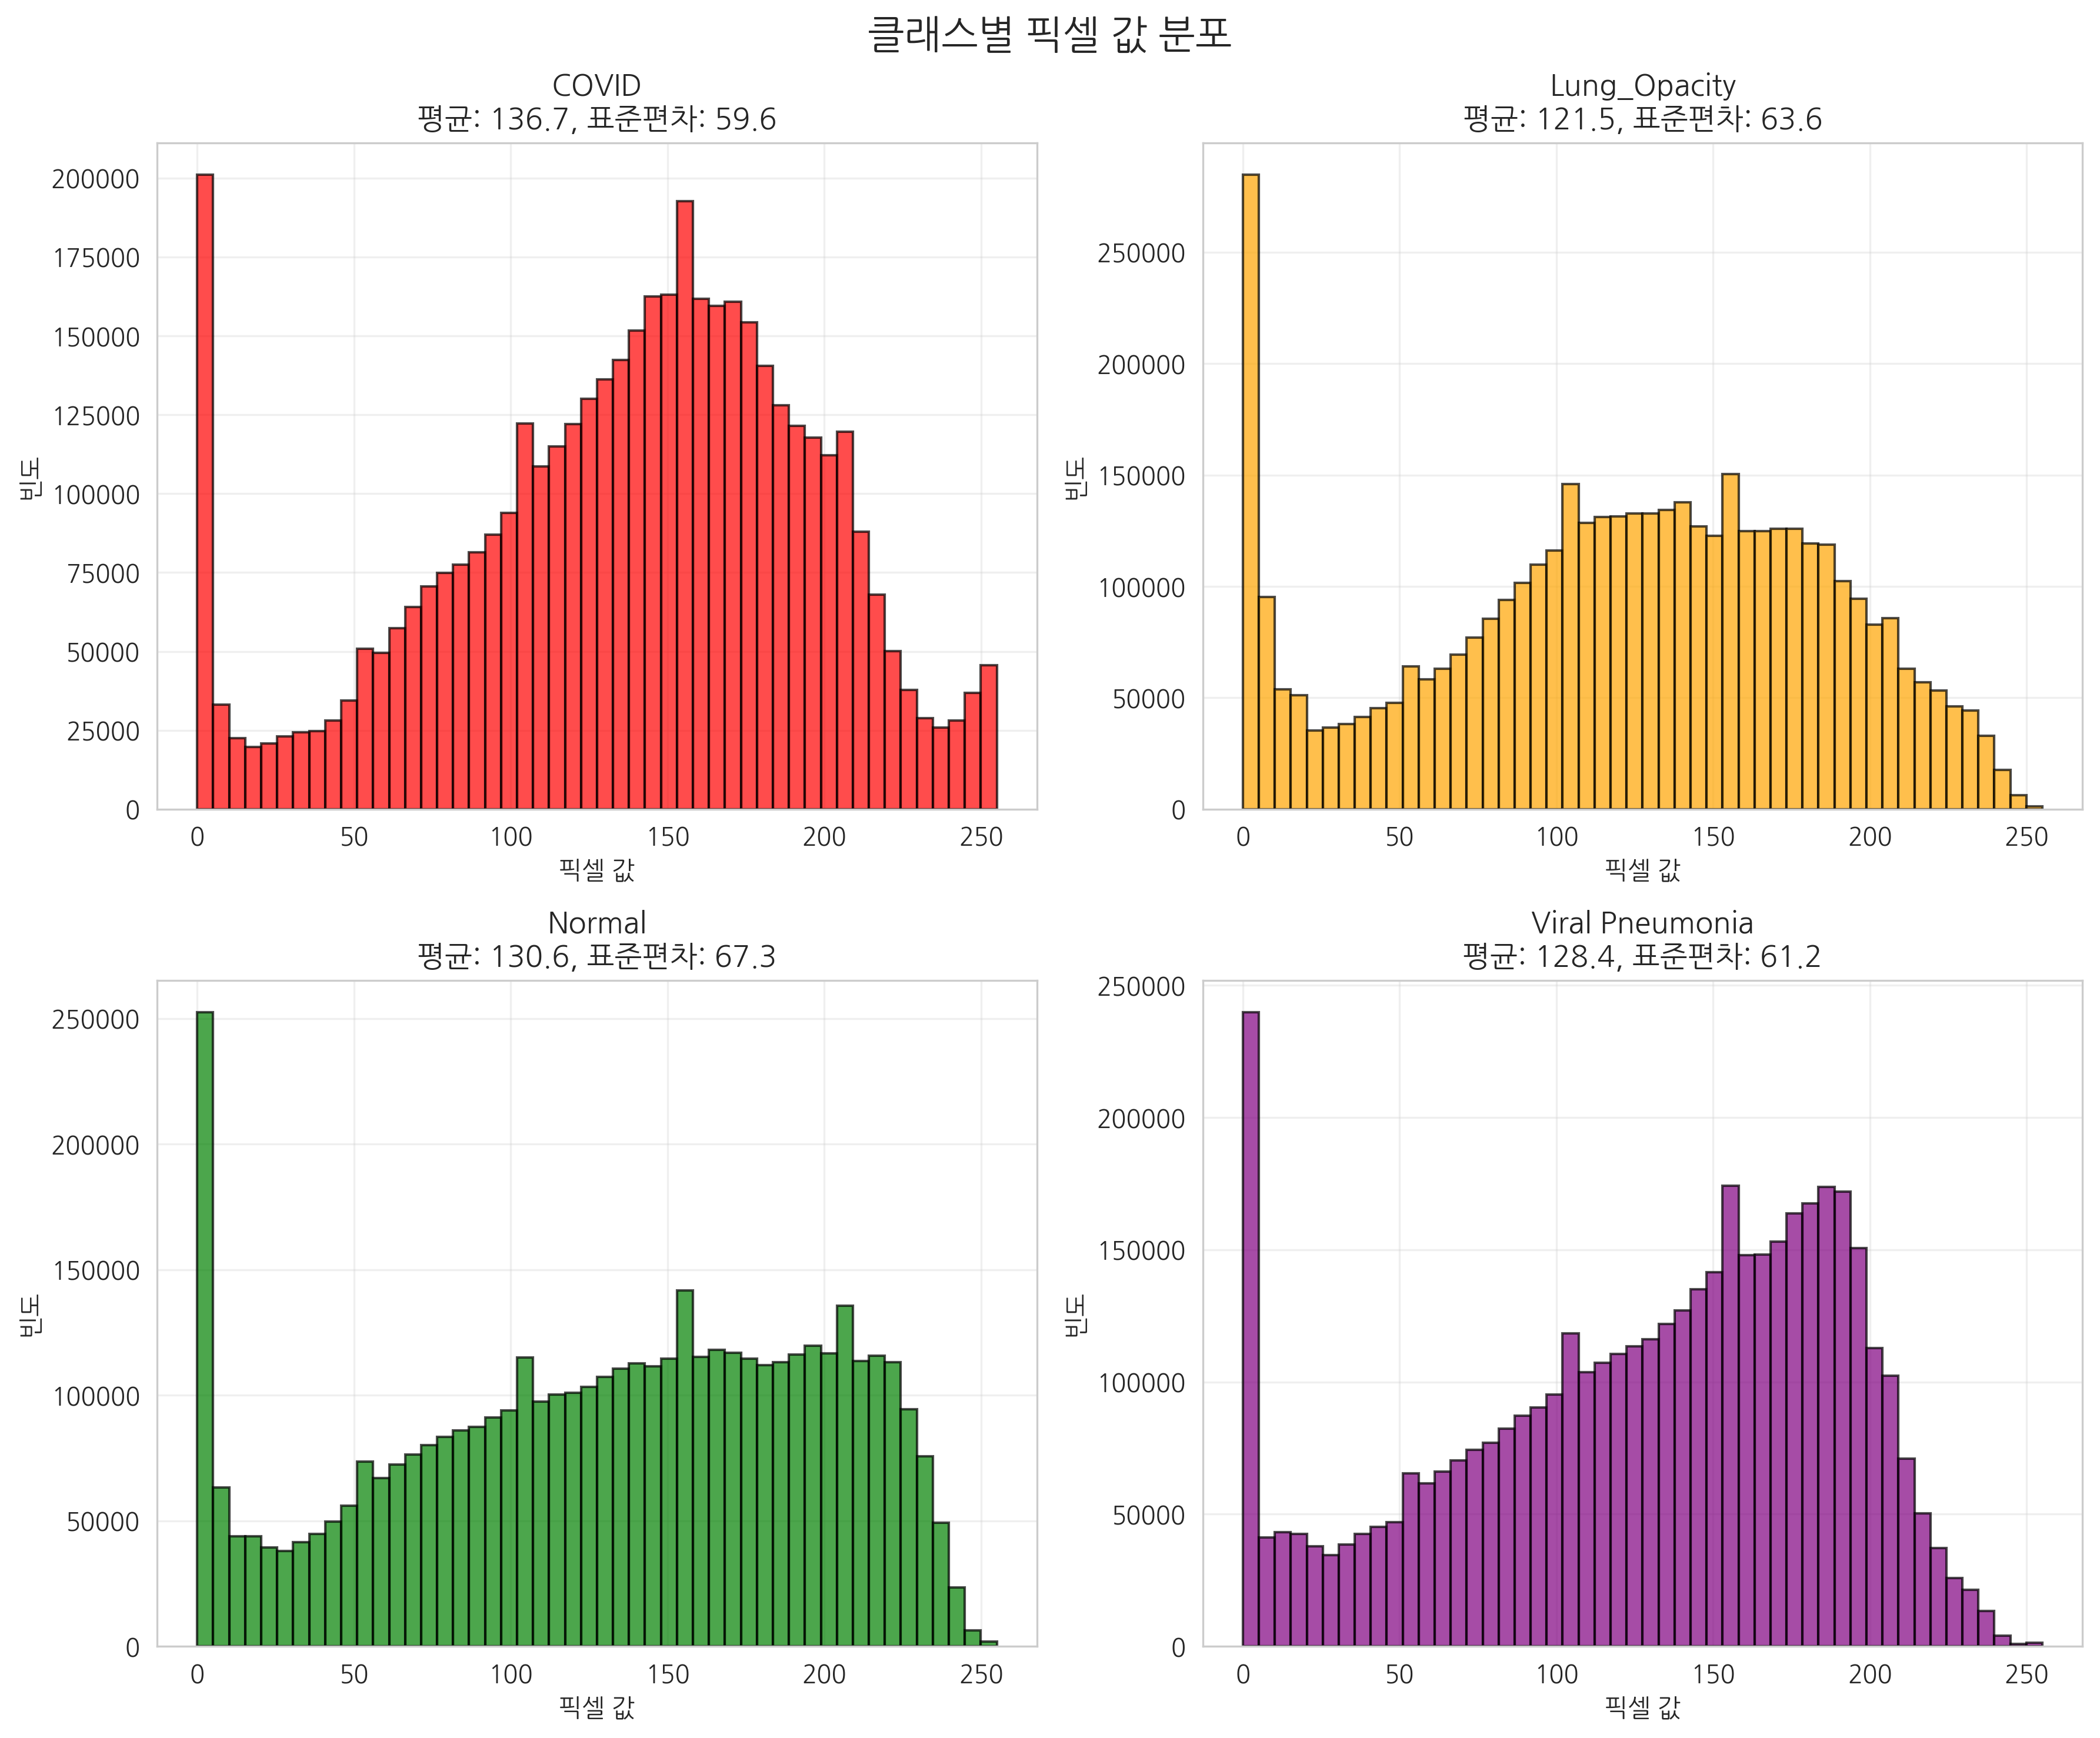


💡 관찰:
   - 모든 클래스가 0~255 범위
   - 클래스별 분포 차이 존재
   - 정규화 필요!


In [10]:
# 클래스별 픽셀 분포
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, class_name in enumerate(class_names):
    image_dir = data_dir / class_name / 'images'
    image_paths = list(image_dir.glob('*.png'))[:50]

    pixel_values = []
    for img_path in image_paths:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        pixel_values.extend(img.flatten())

    ax = axes[idx]
    ax.hist(pixel_values, bins=50, color=colors[idx], alpha=0.7, edgecolor='black')
    ax.set_xlabel('픽셀 값', fontweight='bold')
    ax.set_ylabel('빈도', fontweight='bold')
    ax.set_title(f'{class_name}\n평균: {np.mean(pixel_values):.1f}, '
                f'표준편차: {np.std(pixel_values):.1f}',
                fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('클래스별 픽셀 값 분포',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('pixel_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n💡 관찰:")
print("   - 모든 클래스가 0~255 범위")
print("   - 클래스별 분포 차이 존재")
print("   - 정규화 필요!")

## 💾 5. 전체 데이터 로딩 & 전처리

In [11]:
# 데이터 경로 수집 (메모리 효율적)
def get_file_paths_and_labels(data_dir):
    """이미지 경로와 라벨만 수집 (메모리 효율적)"""

    class_names = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    file_paths = []
    labels = []

    print("📋 파일 경로 수집 중...")

    for class_name in class_names:
        image_dir = data_dir / class_name / 'images'
        image_paths = list(image_dir.glob('*.png'))

        for img_path in image_paths:
            file_paths.append(str(img_path))
            labels.append(class_to_idx[class_name])

        print(f"  {class_name:20s}: {len(image_paths):5d}개")

    print(f"\n✅ 총 {len(file_paths):,}개 파일 경로 수집 완료!")

    return file_paths, labels, class_names

# 파일 경로만 수집 (메모리 절약!)
file_paths, labels, class_names = get_file_paths_and_labels(data_dir)

print(f"\n데이터 정보:")
print(f"  파일 수: {len(file_paths):,}개")
print(f"  클래스: {class_names}")
print(f"  메모리 사용: {len(file_paths) * 100 / 1024:.2f} KB (경로만)")

📋 파일 경로 수집 중...
  COVID               :  3616개
  Lung_Opacity        :  6012개
  Normal              : 10192개
  Viral Pneumonia     :  1345개

✅ 총 21,165개 파일 경로 수집 완료!

데이터 정보:
  파일 수: 21,165개
  클래스: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
  메모리 사용: 2066.89 KB (경로만)


### 메모리 효율적 데이터 로딩

전체 이미지를 메모리에 로드하면 ~13GB 필요!  
→ `tf.data.Dataset` 사용으로 메모리 절약

In [12]:
# 이미지 로드 함수 (tf.data용)
def load_and_preprocess_image(file_path, label, target_size=(224, 224)):
    """단일 이미지 로드 & 전처리"""

    # 이미지 읽기
    img = tf.io.read_file(file_path)
    img = tf.image.decode_png(img, channels=1)  # Grayscale

    # 리사이즈
    img = tf.image.resize(img, target_size)

    # RGB 변환 (3채널)
    img = tf.image.grayscale_to_rgb(img)

    # 0-1 정규화
    img = img / 255.0

    return img, label

print("✅ 전처리 함수 정의 완료!")

✅ 전처리 함수 정의 완료!


In [13]:
# Train/Val Split (경로 기준)
from sklearn.model_selection import train_test_split

train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print("="*60)
print("  데이터 분할")
print("="*60)
print(f"Train: {len(train_paths):,}개 ({len(train_paths)/len(file_paths)*100:.1f}%)")
print(f"Val  : {len(val_paths):,}개 ({len(val_paths)/len(file_paths)*100:.1f}%)")
print("="*60)

# 클래스 분포 확인
print("\nTrain 클래스 분포:")
train_dist = pd.Series(train_labels).value_counts().sort_index()
for idx, count in train_dist.items():
    print(f"  {class_names[idx]:20s}: {count:5d} ({count/len(train_labels)*100:.1f}%)")

print("\nVal 클래스 분포:")
val_dist = pd.Series(val_labels).value_counts().sort_index()
for idx, count in val_dist.items():
    print(f"  {class_names[idx]:20s}: {count:5d} ({count/len(val_labels)*100:.1f}%)")

  데이터 분할
Train: 16,932개 (80.0%)
Val  : 4,233개 (20.0%)

Train 클래스 분포:
  COVID               :  2893 (17.1%)
  Lung_Opacity        :  4809 (28.4%)
  Normal              :  8154 (48.2%)
  Viral Pneumonia     :  1076 (6.4%)

Val 클래스 분포:
  COVID               :   723 (17.1%)
  Lung_Opacity        :  1203 (28.4%)
  Normal              :  2038 (48.1%)
  Viral Pneumonia     :   269 (6.4%)


In [14]:
# tf.data.Dataset 생성 (메모리 효율적!)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Train Dataset
train_dataset = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_dataset = train_dataset.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
train_dataset = train_dataset.shuffle(1000)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(AUTOTUNE)

# Val Dataset
val_dataset = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_dataset = val_dataset.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE)
val_dataset = val_dataset.prefetch(AUTOTUNE)

print("✅ tf.data.Dataset 생성 완료!")
print(f"\nBatch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_dataset)}")
print(f"Val batches: {len(val_dataset)}")
print(f"\n💡 메모리 사용: 배치 단위로만 로드 (약 {BATCH_SIZE * 224 * 224 * 3 * 4 / 1024**2:.1f} MB/batch)")

✅ tf.data.Dataset 생성 완료!

Batch size: 32
Train batches: 530
Val batches: 133

💡 메모리 사용: 배치 단위로만 로드 (약 18.4 MB/batch)


## 🏗️ 7. Baseline CNN 모델

In [15]:
# Simple CNN 모델
def build_baseline_cnn(input_shape=(224, 224, 3), num_classes=4):
    """Baseline CNN for COVID-19 Classification"""

    model = keras.Sequential([
        # Conv Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                     input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        layers.Dropout(0.25),

        # Conv Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        layers.Dropout(0.25),

        # Conv Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        layers.Dropout(0.25),

        # Classifier
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='Baseline_CNN')

    return model

# 모델 생성
baseline_model = build_baseline_cnn()
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,220 (504.77 KB)

 Trainable params: 128,260 (501.02 KB)

 Non-trainable params: 960 (3.75 KB)

In [16]:
# 모델 컴파일
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ 모델 컴파일 완료!")

✅ 모델 컴파일 완료!


## 🏃 8. Baseline 모델 학습

In [17]:
# Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

print("✅ Callbacks 설정 완료!")

✅ Callbacks 설정 완료!


In [18]:
# MLflow 실험
try:
    mlflow.end_run()
except:
    pass

with mlflow.start_run(run_name='Baseline_CNN'):
    mlflow.log_params({
        'model': 'Baseline_CNN',
        'architecture': 'Simple CNN',
        'input_size': '224x224',
        'optimizer': 'adam',
        'epochs': 20,
        'batch_size': BATCH_SIZE
    })

    print("🏃 모델 학습 시작...\n")

    history = baseline_model.fit(
        train_dataset,
        epochs=20,
        validation_data=val_dataset,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # 최종 성능
    final_loss, final_acc = baseline_model.evaluate(val_dataset, verbose=0)

    mlflow.log_metrics({
        'final_val_loss': final_loss,
        'final_val_accuracy': final_acc
    })

    # 모델 저장
    mlflow.keras.log_model(baseline_model, 'model')

    print(f"\n{'='*60}")
    print("  Baseline 모델 학습 완료")
    print('='*60)
    print(f"  Val Loss: {final_loss:.4f}")
    print(f"  Val Accuracy: {final_acc:.4f} ({final_acc*100:.2f}%)")
    print('='*60)

🏃 모델 학습 시작...

Epoch 1/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 74s 111ms/step - accuracy: 0.5453 - loss: 1.3238 - val_accuracy: 0.1788 - val_loss: 6.5795 - learning_rate: 0.0010
Epoch 2/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 51s 92ms/step - accuracy: 0.7184 - loss: 0.7397 - val_accuracy: 0.4833 - val_loss: 1.6337 - learning_rate: 0.0010
Epoch 3/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 49s 89ms/step - accuracy: 0.7733 - loss: 0.5888 - val_accuracy: 0.4833 - val_loss: 1.9176 - learning_rate: 0.0010
Epoch 4/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 50s 90ms/step - accuracy: 0.8104 - loss: 0.4914 - val_accuracy: 0.3451 - val_loss: 2.5890 - learning_rate: 0.0010
Epoch 5/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 49s 90ms/step - accuracy: 0.8346 - loss: 0.4351 - val_accuracy: 0.3012 - val_loss: 3.1110 - learning_rate: 0.0010
Epoch 6/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 49s 89ms/step - accuracy: 0.8634 - loss: 0.3665 - val_accuracy: 0.7352 - val_loss: 0.7556 - learning_rate: 5.0000e-04
Epoch 7/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 52s 94ms/step - 

2026/02/19 13:41:47 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/02/19 13:42:05 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



  Baseline 모델 학습 완료
  Val Loss: 0.4168
  Val Accuracy: 0.8542 (85.42%)
🏃 View run Baseline_CNN at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/6/runs/410b2e1d403147c9bcc2d322d310edaa
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/6


## 📈 9. 모델 평가

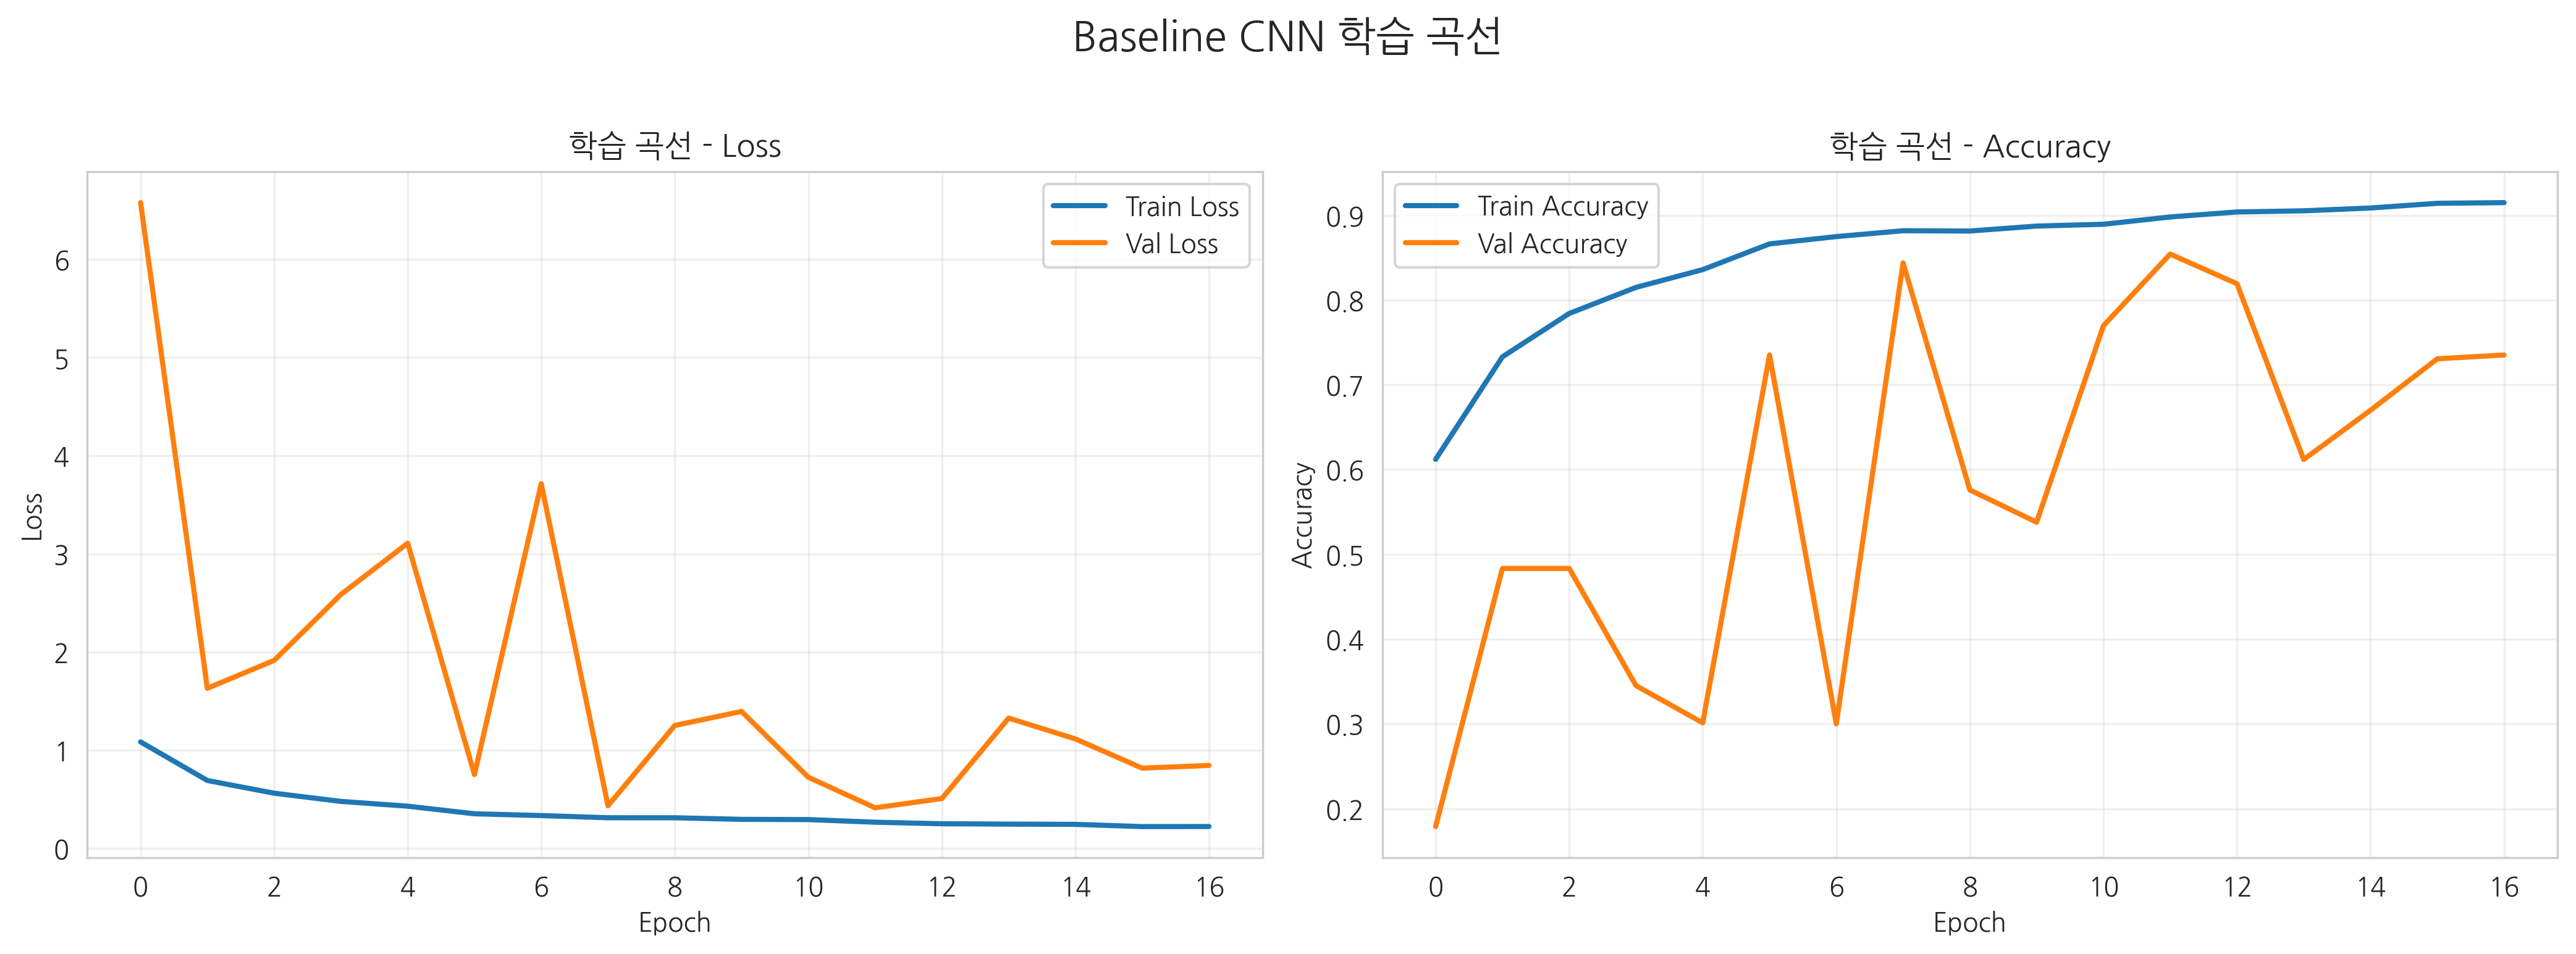

In [19]:
# 학습 곡선
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontweight='bold')
axes[0].set_ylabel('Loss', fontweight='bold')
axes[0].set_title('학습 곡선 - Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontweight='bold')
axes[1].set_ylabel('Accuracy', fontweight='bold')
axes[1].set_title('학습 곡선 - Accuracy', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Baseline CNN 학습 곡선',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

🔮 Validation set 예측 중...


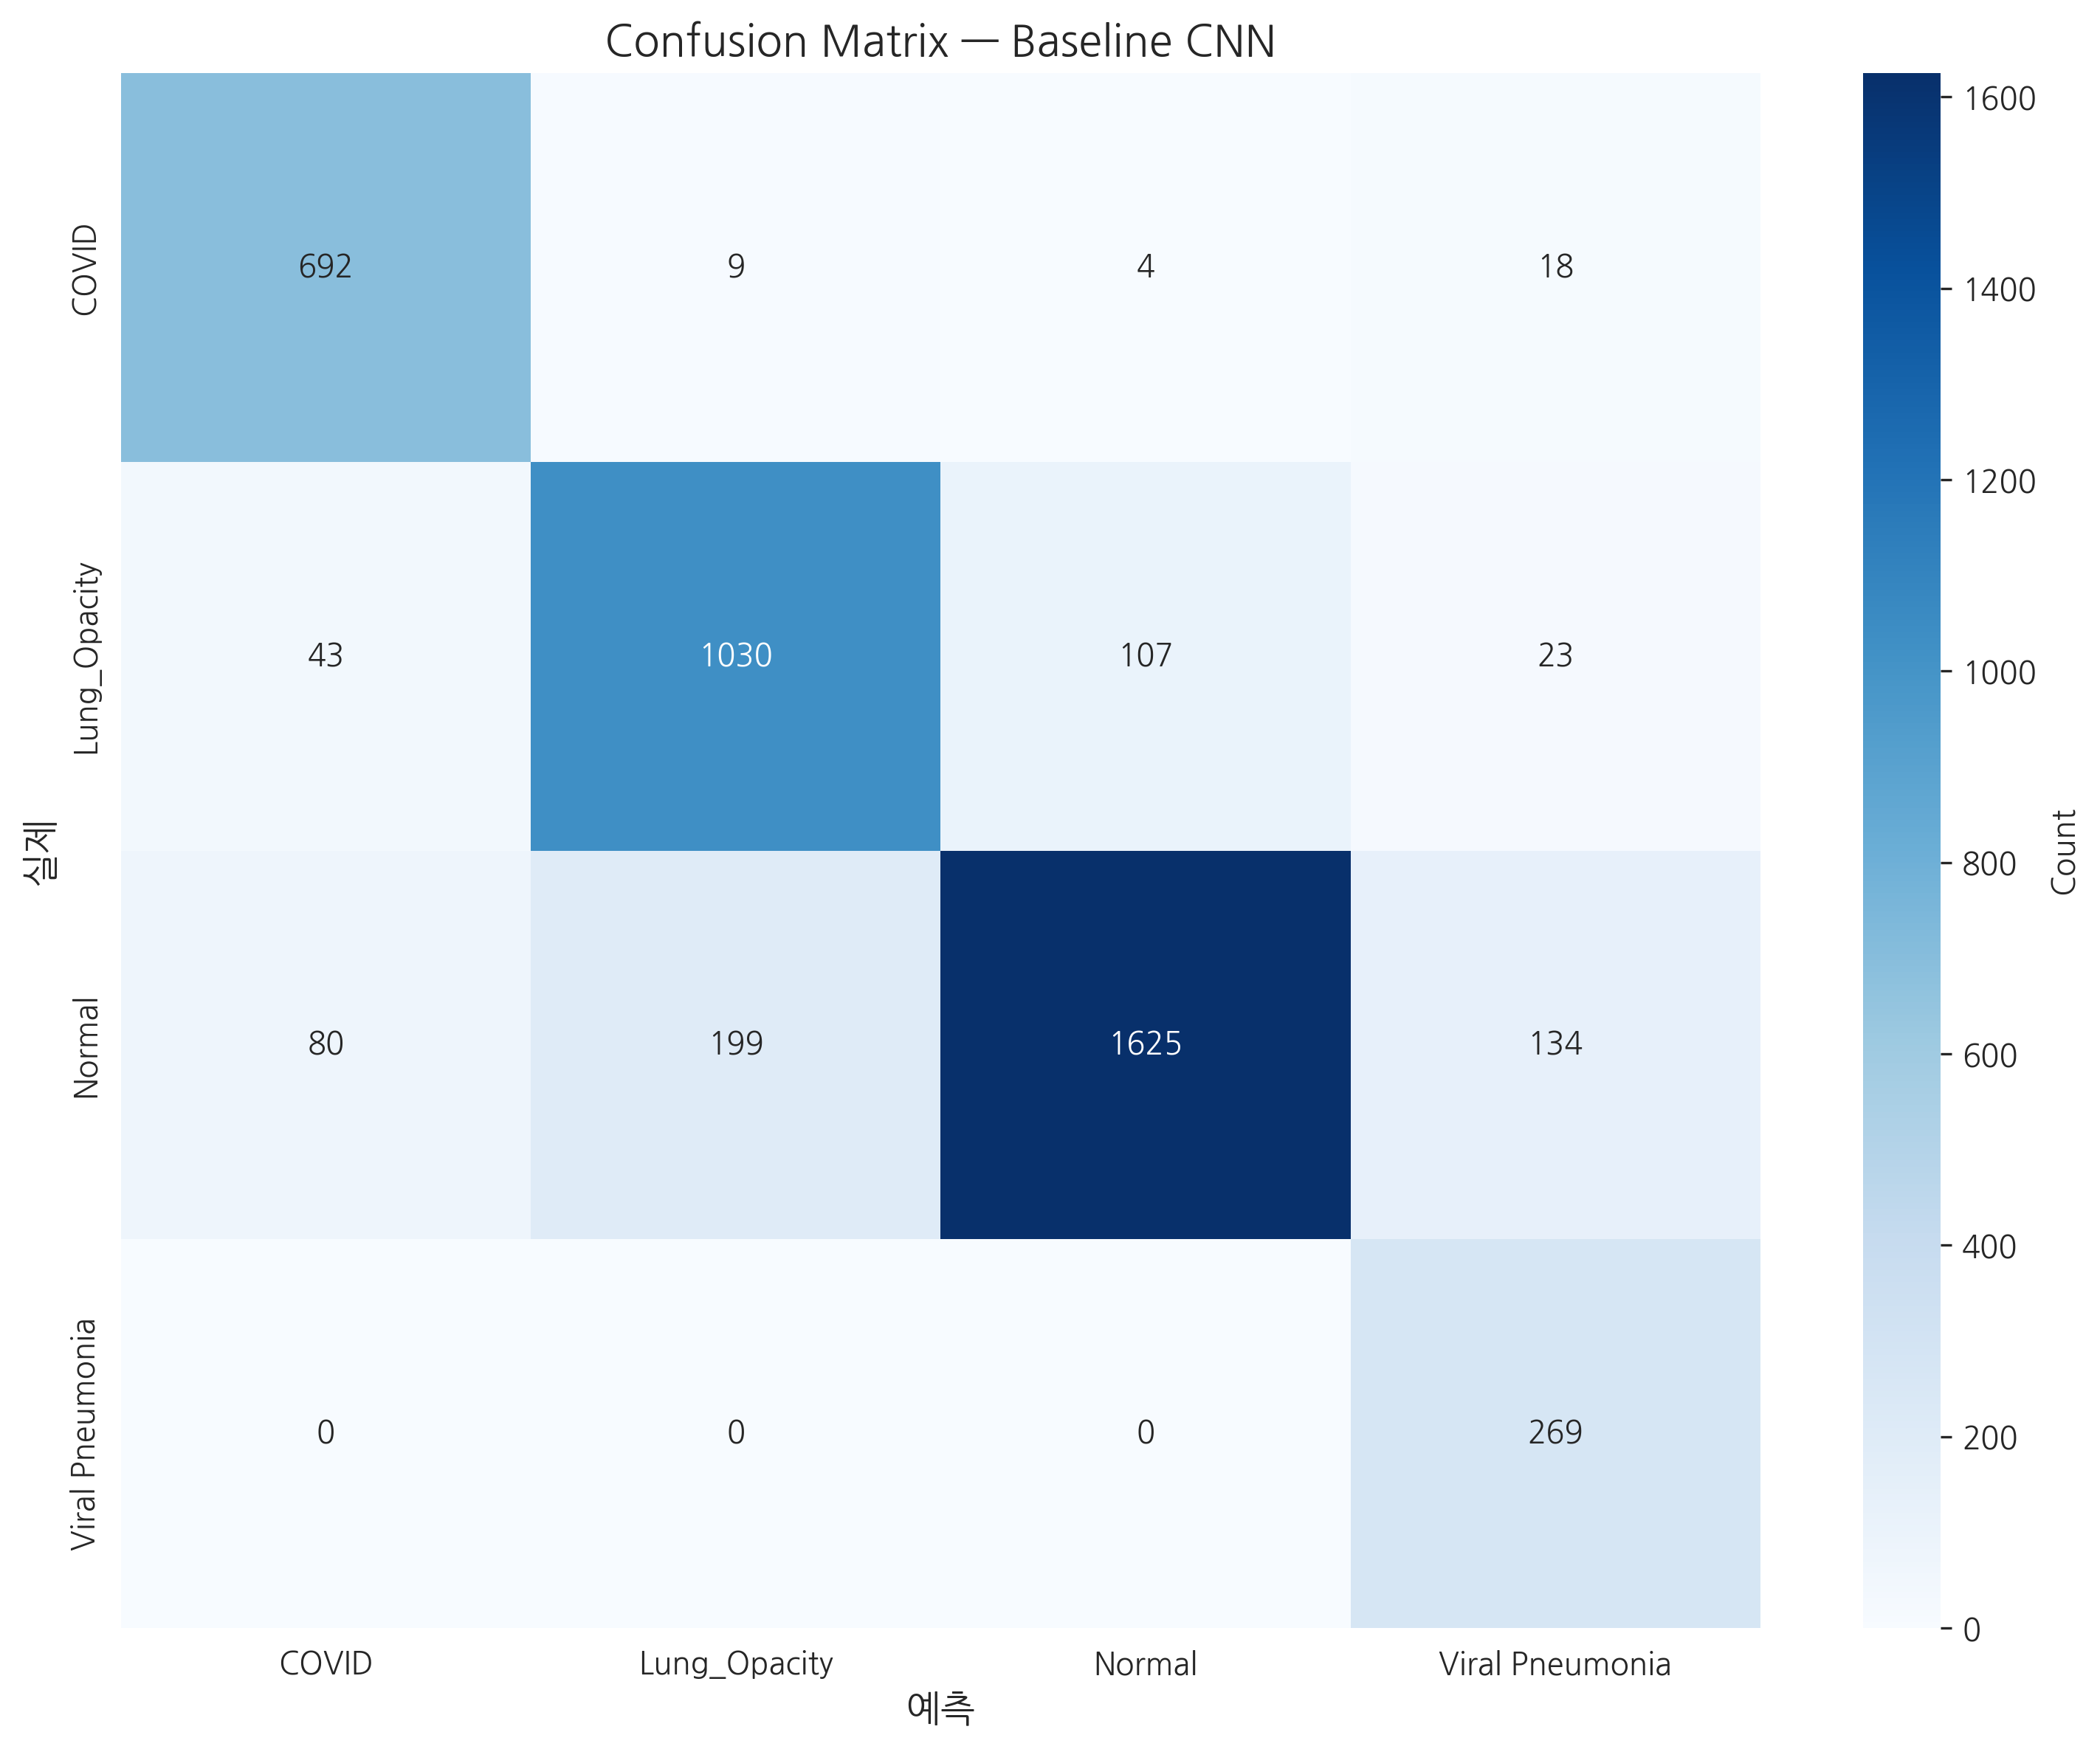

In [20]:
# Confusion Matrix (Val Dataset 전체 예측)
print("🔮 Validation set 예측 중...")

y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = baseline_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('예측', fontweight='bold', fontsize=12)
plt.ylabel('실제', fontweight='bold', fontsize=12)
plt.title('Confusion Matrix — Baseline CNN',
          fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

In [21]:
# Classification Report
report = classification_report(y_true, y_pred,
                              target_names=class_names,
                              digits=4)

print("="*60)
print("  Classification Report")
print("="*60)
print(report)
print("="*60)

# Per-class Metrics
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average=None
)

print("\n클래스별 성능:")
print("-"*60)
for i, class_name in enumerate(class_names):
    print(f"{class_name:20s}: "
          f"Precision={precision[i]:.4f}, "
          f"Recall={recall[i]:.4f}, "
          f"F1={f1[i]:.4f}")
print("-"*60)

# COVID-19 Recall 강조
covid_idx = class_names.index('COVID')
print(f"\n⚠️ COVID-19 Recall: {recall[covid_idx]:.4f} ({recall[covid_idx]*100:.2f}%)")
print(f"   → {int(recall[covid_idx]*support[covid_idx])}/{support[covid_idx]} "
      f"COVID 환자 탐지")

  Classification Report
                 precision    recall  f1-score   support

          COVID     0.8491    0.9571    0.8999       723
   Lung_Opacity     0.8320    0.8562    0.8439      1203
         Normal     0.9361    0.7974    0.8612      2038
Viral Pneumonia     0.6059    1.0000    0.7546       269

       accuracy                         0.8542      4233
      macro avg     0.8057    0.9027    0.8399      4233
   weighted avg     0.8706    0.8542    0.8561      4233


클래스별 성능:
------------------------------------------------------------
COVID               : Precision=0.8491, Recall=0.9571, F1=0.8999
Lung_Opacity        : Precision=0.8320, Recall=0.8562, F1=0.8439
Normal              : Precision=0.9361, Recall=0.7974, F1=0.8612
Viral Pneumonia     : Precision=0.6059, Recall=1.0000, F1=0.7546
------------------------------------------------------------

⚠️ COVID-19 Recall: 0.9571 (95.71%)
   → 692/723 COVID 환자 탐지


## 🧠 10. 핵심 개념 정리

### 오늘 배운 것

**1. COVID-19 Radiography Database**
- 4-class: COVID, Normal, Lung_Opacity, Viral Pneumonia
- 21,165개 이미지
- Class Imbalance 존재 (48% vs 6%)

**2. 의료 이미지 특성**
- Grayscale → RGB 변환 (Transfer Learning용)
- 224×224 리사이즈
- 0-1 정규화

**3. 평가 지표**
- Accuracy: 전체 정확도
- Precision: 예측한 것 중 맞은 비율
- Recall: 실제 중 찾아낸 비율 ← **중요!**
- F1-score: Precision & Recall 조화평균

**4. 의료 AI 윤리**
- False Negative (FN): COVID 놓침 → 위험!
- Recall 최대화 우선
- AI는 보조 도구, 최종 판단은 의사

**5. Baseline 성능**
```
Val Accuracy: ~70-80%
COVID Recall: ~70-75%

→ Day 4-2에서 Transfer Learning으로 개선!
```

---

### Day 4-2 예고

**Transfer Learning (ResNet50)**
- ImageNet Pretrained 모델
- Fine-tuning 전략
- Data Augmentation
- 목표: Accuracy 85%+, Recall(COVID) 80%+

축하합니다! Day 4-1 완료! 🎉

## ✅ Day 4-1 완료 체크리스트

- [ ] COVID-19 데이터셋 다운로드
- [ ] 클래스 분포 확인 (Imbalance)
- [ ] 샘플 이미지 시각화
- [ ] 픽셀 값 분포 분석
- [ ] Train/Val Split (Stratified)
- [ ] Baseline CNN 모델 구축
- [ ] 모델 학습 (MLflow 기록)
- [ ] 학습 곡선 시각화
- [ ] Confusion Matrix 생성
- [ ] Classification Report 확인
- [ ] COVID Recall 확인
- [ ] 의료 AI 윤리 이해

## 🎯 다음 단계 (Day 4-2)

**Day 4-2: Transfer Learning**

**내용:**
- ImageNet Pretrained ResNet50
- Feature Extraction vs Fine-tuning
- Data Augmentation (회전, 이동, 확대)
- Learning Rate Scheduling

**목표:**
- Val Accuracy: 85%+
- COVID Recall: 80%+
- 모든 클래스 F1 > 0.75

수고하셨습니다! 🚀